In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing
### Handing Missing Values

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())

### Feature Engineering

In [4]:
# adding new column age from the column year_birth

df["Age"] = 2026 - df["Year_Birth"]

In [5]:
# adding new column called tenuer for the date of joing to convert into simple number 
# which the difference of how much since the costumer join from max day

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refference_day = df["Dt_Customer"].max()                            # max value of days

df["Customer_tenuer_days"] = (refference_day - df["Dt_Customer"]).dt.days           # when we subtract teo dates give date (Timedelta('500 days')) 
                                                                                    # but using .dt.days give you only no. of days (500)

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenuer_days'],
      dtype='object')

In [6]:
# adding all product value which had spend in one (line add = meat+fish+friut.....)

# total spending

df["total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [7]:
# children

df["total_chidren"] = df["Kidhome"] + df["Teenhome"]

In [8]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [9]:
# Education  replacing values with graduate,undergraduate, postgraduate

df["Education"] = df["Education"].replace({
    "Basic" : "Under-Graduate", "2n Cycle" : "Under-Graduate",
    "Graduation" : "Graduate",
    "PhD" : "Post-Graduate", "Master" : "Post-Graduate"
})

In [10]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [11]:
# marige_satus 

df["Living_with"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner",
    "Single":"Alone", "Divorced":"Alone","Widow":"Alone","Alone":"Alone","Absurd":"Alone","YOLO":"Alone"
})

In [12]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [27]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenuer_days', 'total_spending',
       'total_chidren', 'Living_with'],
      dtype='object')

### Drop Columns

In [13]:
cols = ["ID","Year_Birth","Kidhome","Teenhome","Dt_Customer","Marital_Status"]
spending_cols = ["MntWines", "MntFruits","MntMeatProducts", "MntFishProducts", "MntSweetProducts","MntGoldProds"]

cols_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_drop)

In [35]:
df_cleaned.shape

(2240, 15)

In [36]:
df.shape

(2240, 27)

In [14]:
df_cleaned.head(2)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenuer_days,total_spending,total_chidren,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone


### Outliers

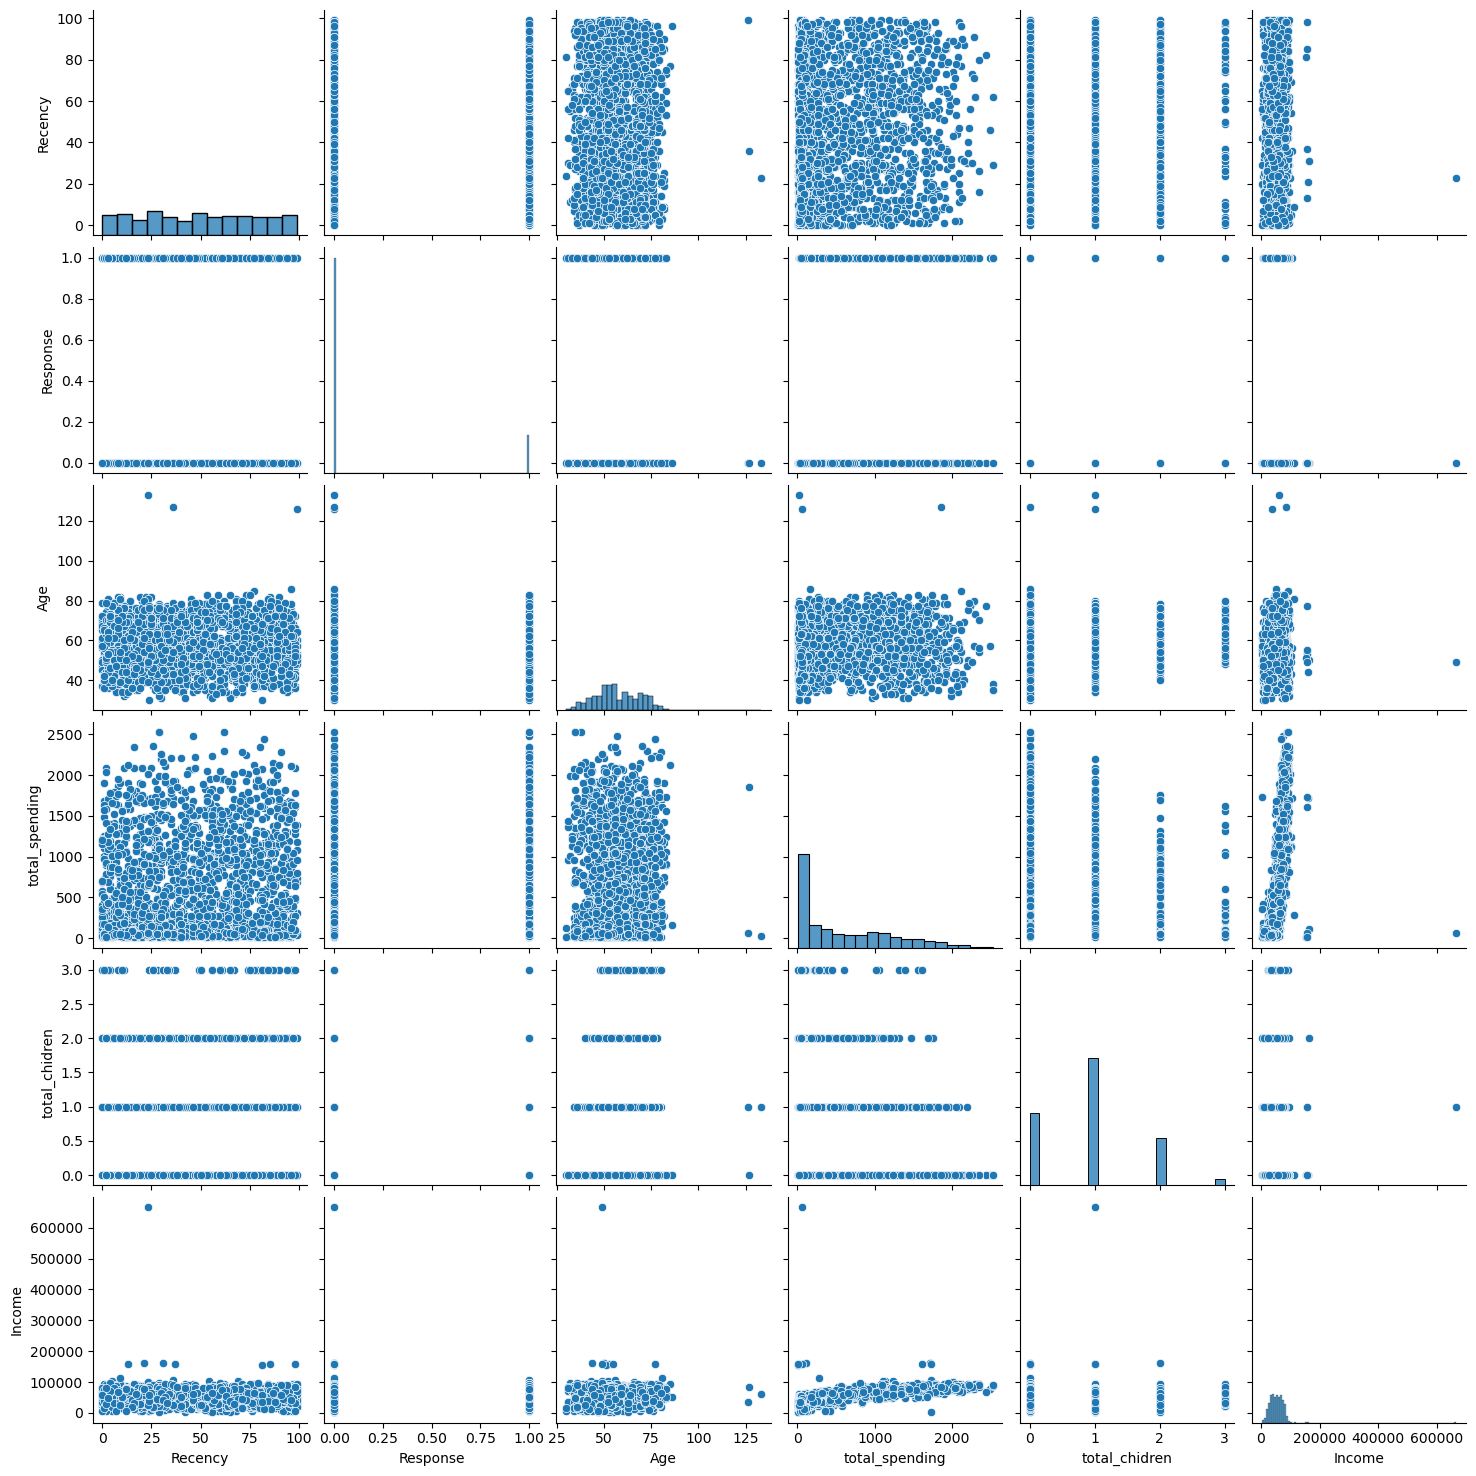

In [15]:
# Visualize Outliers

cols = ["Income","Recency","Response","Age","total_spending","total_chidren"]
col = ["Recency","Response","Age","total_spending","total_chidren","Income"]
sns.pairplot(df_cleaned[col])

In [17]:
# Removing Outliers

print("data with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] <600_000)]

print("data without outliers:", len(df_cleaned))

data with outliers: 2240
data without outliers: 2236


### Heatmap

In [19]:
# corelatiom matrix

corr = df_cleaned.corr(numeric_only=True)

<Axes: >

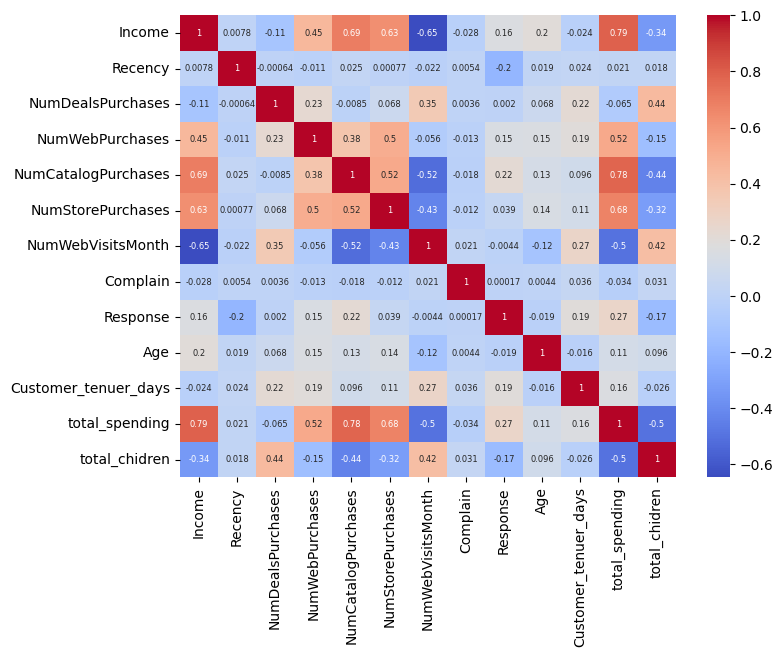

In [22]:
# heatmap

plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size":6},
    cmap = "coolwarm"
)

### Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
ohe = OneHotEncoder()

cols = ["Education","Living_with"]

encd_col = ohe.fit_transform(df_cleaned[cols])

In [27]:
encd_df = pd.DataFrame(encd_col.toarray(), columns = ohe.get_feature_names_out(cols), index = df_cleaned.index)

In [30]:
encoded_df = pd.concat([df_cleaned.drop(columns=cols),encd_df],axis=1)

In [31]:
encoded_df.shape

(2236, 18)

### Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = encoded_df

X_scaled = scaler.fit_transform(X)

### Visualization

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

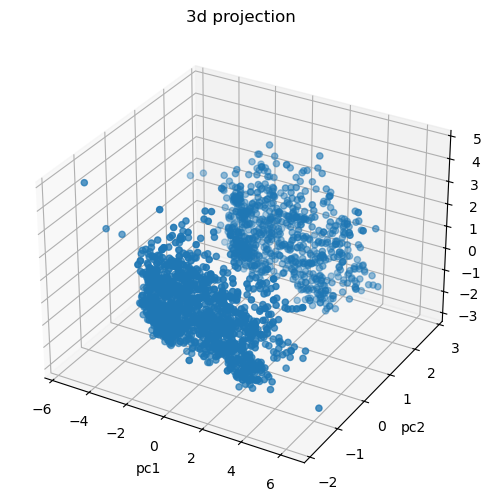

In [57]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("pc1")
ax.set_ylabel("pc2")
ax.set_zlabel("pc3")
ax.set_title("3d projection")

In [54]:
pca.explained_variance_ratio_                          # show how mauch data had capture (0.23+0.11=0.34, means 34% data only)

array([0.23163158, 0.11385454, 0.10405815])

## Analizing k

### Elbow Method

In [60]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [61]:
wcss = [] 

for k in range(1,11):
    kmeans = KMeans(n_clusters = k ,random_state=42)
    kmeans.fit_predict(X_pca)

    wcss.append(kmeans.inertia_)

In [65]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")

optimal_k = knee.elbow

In [66]:
optimal_k

np.int64(4)

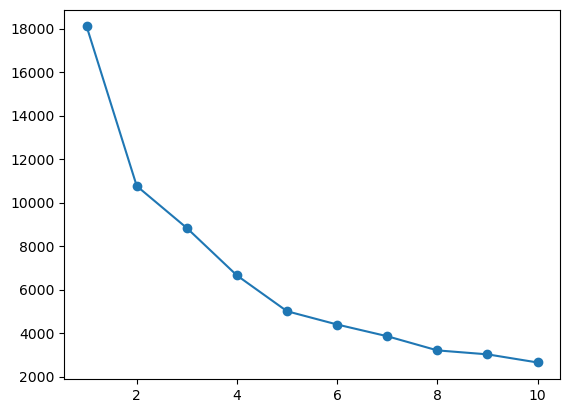

In [67]:
plt.plot(range(1,11), wcss, marker="o")

### silhouette score

Text(0, 0.5, 'silhouette_score')

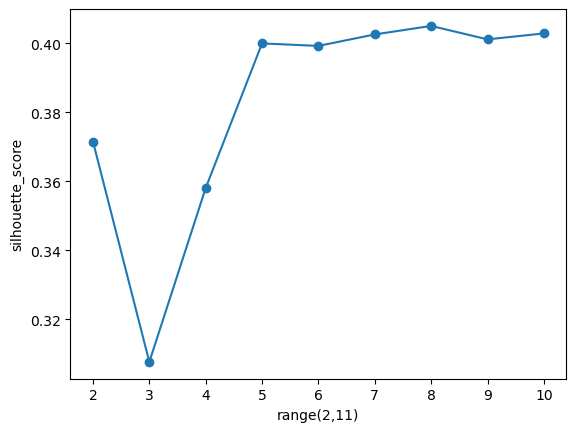

In [70]:
from sklearn.metrics import silhouette_score                   # pick the highest score value in this plot is 8 but we want balanced value 
                                                               # and choice the value where elbow and silhouette score intersect or near that 
scores = [] 
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot

plt.plot(range(2, 11), scores, marker = "o")
plt.xlabel("range(2,11)")
plt.ylabel("silhouette_score")

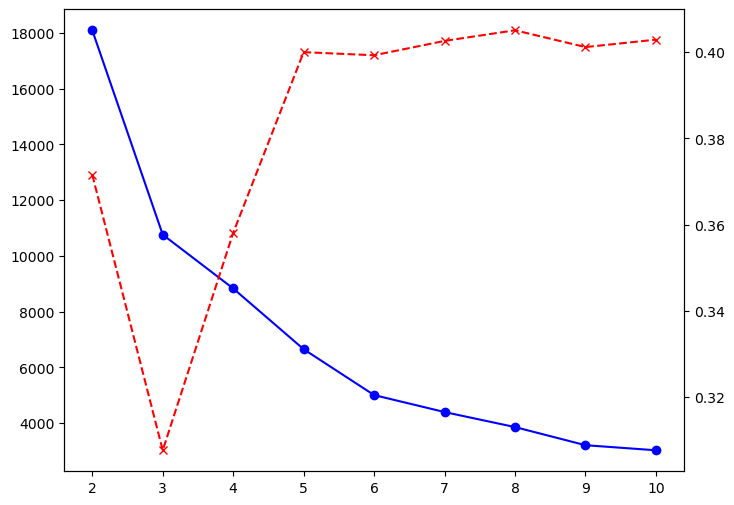

In [74]:
# combine plot of elbow ans silhouette score

k_range = range(2,11)                                                       # choice the value where elbow and silhouette score intersect or near that

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker = "o", color="blue")

ax2 = ax1.twinx()

ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")

### Apllying Models

In [75]:
# KMEANS

kmeans = KMeans(n_clusters = 4)

labels_kmeans = kmeans.fit_predict(X_pca)


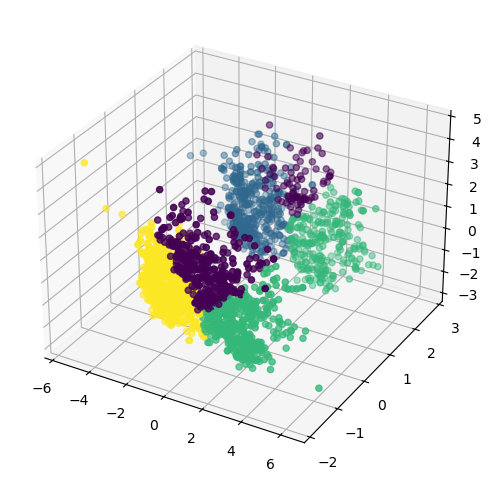

In [79]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)

In [83]:
### AGGLOMIRATIVE CLUSTERING

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters = 4, linkage = "ward")

labels_agg = agg.fit_predict(X_pca)

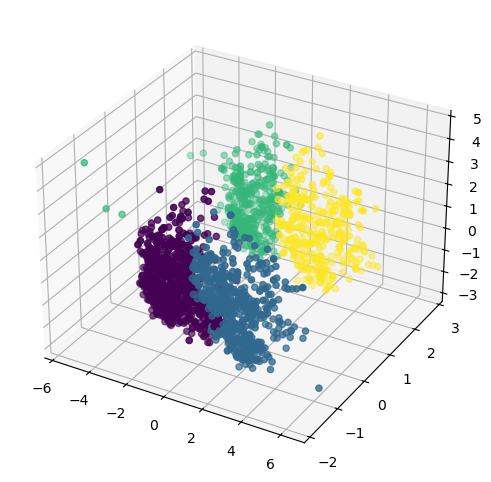

In [87]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2], c=labels_agg)

## Characterization of clusters

In [98]:
df_cleaned=df_cleaned.drop("labels", axis=1)
df_cleaned["Clusters"] = labels_agg

In [99]:
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenuer_days,total_spending,total_chidren,Living_with,Clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Post-Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner,0
2236,Post-Graduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner,0
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone,3
2238,Post-Graduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner,1


<Axes: xlabel='Clusters', ylabel='count'>

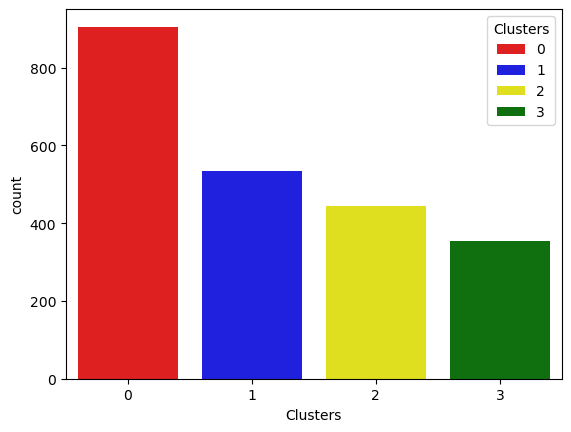

In [100]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=df_cleaned["Clusters"],palette = pal, hue=df_cleaned["Clusters"])

<Axes: xlabel='total_spending', ylabel='Income'>

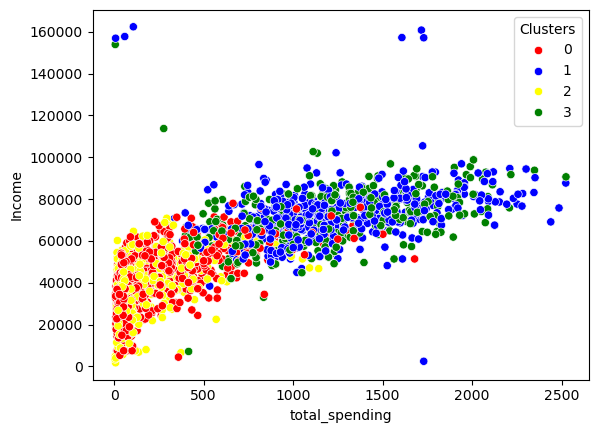

In [104]:
sns.scatterplot(x=df_cleaned["total_spending"], y=df_cleaned["Income"], hue=df_cleaned["Clusters"], palette=pal)

### Cluster summary

In [107]:
X["Clusters"] = labels_agg
cluster_summary = X.groupby("Clusters").mean()

In [109]:
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenuer_days  total_spending  \
Clu